## 03 Procesamiento de Data

1. Revisión de datos (primeros 5 y ultimos 5)
2. Eliminación de datos que no son relevantes en base a la exploración
3. Ingeniería de atributos
4. Separacion de variables categoricas y numericas
5. Variables numéricas
   1. Identificación de Outliers (IQR)
   2. Imputación de Nulos mediante Random forest regresor
   3. Medimos la correlación de varibales numéricas
6. Variables Categóricas
   1. Medimos la correlación (Chi-cuadrado) 
7. Unión de datos trabajados
8. Guardado de datos preprocesados.

In [2]:
import pandas as pd

data_row = pd.read_csv('../Data/Row/Flujo vehicular registrado en peajes_2014-2025_II.csv', encoding='latin-1')

df_prep = data_row.copy()

In [3]:
df_prep.head(5)

,ID,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,NOMBRE_PEAJE,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,...,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO
0,0,Concesionado,22PE5NACS1,San Martín,Aguas Claras,2099,8070.0,0,2586.0,2374.0,...,8.0,10169,328.0,9515,306.9,19684,635.0,2014,1,201401
1,1,Concesionado,04PE1SCAM1,Arequipa,Camaná,0,24644.0,0,6502.0,4622.0,...,213.0,24644,795.0,24730,797.7,49374,1592.7,2014,1,201401
2,2,Concesionado,21PE3SCRO1,Puno,Caracoto,33643,82139.0,5797,17981.0,5307.0,...,12.0,115782,3734.9,37326,1204.1,153108,4939.0,2014,1,201401
3,3,Concesionado,12PE3NCRA1,Junín,Casaracra-Concesión,10,46944.0,0,16981.0,18585.0,...,135.0,46954,1514.6,62622,2020.1,109576,3534.7,2014,1,201401
4,4,Concesionado,08PE3SCSC1,Cusco,Ccasacancha (Huillque),0,23831.0,0,4709.0,3941.0,...,95.0,23831,768.7,13906,448.6,37737,1217.3,2014,1,201401


In [4]:
# Eliminamos las oclumnas que no nos sirven

df_prep.drop(columns= ['ID', 'NOMBRE_PEAJE'] , axis=1, inplace=True)

df_prep.head(5)

,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,...,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO
0,Concesionado,22PE5NACS1,San Martín,2099,8070.0,0,2586.0,2374.0,720.0,315.0,...,8.0,10169,328.0,9515,306.9,19684,635.0,2014,1,201401
1,Concesionado,04PE1SCAM1,Arequipa,0,24644.0,0,6502.0,4622.0,1654.0,3028.0,...,213.0,24644,795.0,24730,797.7,49374,1592.7,2014,1,201401
2,Concesionado,21PE3SCRO1,Puno,33643,82139.0,5797,17981.0,5307.0,1150.0,1737.0,...,12.0,115782,3734.9,37326,1204.1,153108,4939.0,2014,1,201401
3,Concesionado,12PE3NCRA1,Junín,10,46944.0,0,16981.0,18585.0,4463.0,3058.0,...,135.0,46954,1514.6,62622,2020.1,109576,3534.7,2014,1,201401
4,Concesionado,08PE3SCSC1,Cusco,0,23831.0,0,4709.0,3941.0,447.0,769.0,...,95.0,23831,768.7,13906,448.6,37737,1217.3,2014,1,201401


In [5]:
# Feature Enginnering

df_prep['Pandemia'] = df_prep['PERIODO'].apply(lambda x: 1 if x in {202003, 202004, 202005, 202006, 202007} else 0 )


df_prep.head(5)

,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,...,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,Pandemia
0,Concesionado,22PE5NACS1,San Martín,2099,8070.0,0,2586.0,2374.0,720.0,315.0,...,10169,328.0,9515,306.9,19684,635.0,2014,1,201401,0
1,Concesionado,04PE1SCAM1,Arequipa,0,24644.0,0,6502.0,4622.0,1654.0,3028.0,...,24644,795.0,24730,797.7,49374,1592.7,2014,1,201401,0
2,Concesionado,21PE3SCRO1,Puno,33643,82139.0,5797,17981.0,5307.0,1150.0,1737.0,...,115782,3734.9,37326,1204.1,153108,4939.0,2014,1,201401,0
3,Concesionado,12PE3NCRA1,Junín,10,46944.0,0,16981.0,18585.0,4463.0,3058.0,...,46954,1514.6,62622,2020.1,109576,3534.7,2014,1,201401,0
4,Concesionado,08PE3SCSC1,Cusco,0,23831.0,0,4709.0,3941.0,447.0,769.0,...,23831,768.7,13906,448.6,37737,1217.3,2014,1,201401,0


In [6]:
# Separacion de variables por numericas y categoricas

df_prep_num = df_prep.select_dtypes(include=['int64', 'float64','number'])
df_prep_cat = df_prep.select_dtypes(include=['object', 'category'])

### Trabajamos las variables numéricas

In [7]:
# Identificamos outliers numéricos

# Podemos usar z-score (Cuando tenemos gran cantidad de datos y una distribución normal) o iqr (Cuando la cantida de datos es pqueñay tiene una tendencia hacia un lado.)
Q1 = df_prep_num.quantile(0.25)
Q3 = df_prep_num.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

df_prep_filtered_num = df_prep_num[(df_prep_num > lower_bound) & (df_prep_num < upper_bound)]

df_prep_filtered_num.count()


VEH_LIGEROS_TAR_DIF         8526
VEH_LIGEROS_AUTOMOVILES     9645
VEH_PESADOS_TAR_DIF            0
VEH_PESADOS__2E             9728
VEH_PESADOS_3E              9386
VEH_PESADOS_4E              9648
VEH_PESADOS_5E              9632
VEH_PESADOS_6E              9767
VEH_PESADOS_7E              9767
VEH_LIGEROS_TOTAL           9622
VEH_LIGEROS_IMD             9610
VEH_PESADOS_TOTAL           9589
VEH_PESADOS_IMD             9586
VEH_TOTAL                   9779
VEH_IMD                     9783
ANIO                       10781
MES                        10781
PERIODO                    10781
Pandemia                       0
dtype: int64

In [8]:
# Imputamos Nulos.
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

rf_optimizado = RandomForestRegressor(
    n_jobs=-1,        
    n_estimators=10,  
    max_depth=10,     
    random_state=42  
)

imputer_num = IterativeImputer(estimator=rf_optimizado, max_iter=5, verbose=2)

df_num_imputed = imputer_num.fit_transform(df_prep_filtered_num)

df_num_imputed

[IterativeImputer] Completing matrix with shape (10781, 17)
[IterativeImputer] Ending imputation round 1/5, elapsed time 2.81
[IterativeImputer] Change: 436192.6075923052, scaled tolerance: 214.882 
[IterativeImputer] Ending imputation round 2/5, elapsed time 5.56
[IterativeImputer] Change: 38633.46794614182, scaled tolerance: 214.882 
[IterativeImputer] Ending imputation round 3/5, elapsed time 8.22
[IterativeImputer] Change: 33808.64707176419, scaled tolerance: 214.882 
[IterativeImputer] Ending imputation round 4/5, elapsed time 10.94
[IterativeImputer] Change: 33789.145696392494, scaled tolerance: 214.882 
[IterativeImputer] Ending imputation round 5/5, elapsed time 13.79
[IterativeImputer] Change: 26209.240610214987, scaled tolerance: 214.882 


c:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\impute\_iterative.py:785: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


array([[1.02814804e+02, 8.07000000e+03, 2.58600000e+03, ...,
        2.01400000e+03, 1.00000000e+00, 2.01401000e+05],
       [0.00000000e+00, 2.46440000e+04, 6.50200000e+03, ...,
        2.01400000e+03, 1.00000000e+00, 2.01401000e+05],
       [7.21120653e+00, 8.21390000e+04, 1.79810000e+04, ...,
        2.01400000e+03, 1.00000000e+00, 2.01401000e+05],
       ...,
       [0.00000000e+00, 3.10780000e+04, 3.20900000e+03, ...,
        2.02500000e+03, 6.00000000e+00, 2.02506000e+05],
       [0.00000000e+00, 1.17240000e+02, 4.43000000e+01, ...,
        2.02500000e+03, 6.00000000e+00, 2.02506000e+05],
       [0.00000000e+00, 1.26470000e+04, 4.03900000e+03, ...,
        2.02500000e+03, 6.00000000e+00, 2.02506000e+05]])

In [9]:
df_num_imputed = pd.DataFrame(df_num_imputed, columns=df_prep_filtered_num.drop(columns=['Pandemia', 'VEH_PESADOS_TAR_DIF']).columns)

df_num_imputed.head()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO
0,102.814804,8070.0,2586.0,2374.0,720.0,315.0,3512.0,8.0,10169.000000,328.000000,9515.0,306.9,19684.0,635.0,2014.0,1.0,201401.0
1,0.000000,24644.0,6502.0,4622.0,1654.0,3028.0,8711.0,213.0,24644.000000,795.000000,24730.0,797.7,49374.0,1592.7,2014.0,1.0,201401.0
2,7.211207,82139.0,17981.0,5307.0,1150.0,1737.0,5342.0,12.0,85932.622101,2851.164583,37326.0,1204.1,153108.0,4939.0,2014.0,1.0,201401.0
3,10.000000,46944.0,16981.0,18585.0,4463.0,3058.0,19400.0,135.0,46954.000000,1514.600000,62622.0,2020.1,109576.0,3534.7,2014.0,1.0,201401.0
4,0.000000,23831.0,4709.0,3941.0,447.0,769.0,3945.0,95.0,23831.000000,768.700000,13906.0,448.6,37737.0,1217.3,2014.0,1.0,201401.0


In [10]:
df_num_imputed.columns

Index(['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS__2E',
       'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E',
       'VEH_PESADOS_7E', 'VEH_LIGEROS_TOTAL', 'VEH_LIGEROS_IMD',
       'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL', 'VEH_IMD', 'ANIO',
       'MES', 'PERIODO'],
      dtype='object')

In [11]:
df_num_imputed.drop(columns=['VEH_LIGEROS_TOTAL',
       'VEH_LIGEROS_IMD', 'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL',
       'VEH_IMD'])

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,ANIO,MES,PERIODO
0,102.814804,8070.00,2586.0,2374.0,720.000000,315.000000,3512.000000,8.00000,2014.0,1.0,201401.0
1,0.000000,24644.00,6502.0,4622.0,1654.000000,3028.000000,8711.000000,213.00000,2014.0,1.0,201401.0
2,7.211207,82139.00,17981.0,5307.0,1150.000000,1737.000000,5342.000000,12.00000,2014.0,1.0,201401.0
3,10.000000,46944.00,16981.0,18585.0,4463.000000,3058.000000,19400.000000,135.00000,2014.0,1.0,201401.0
4,0.000000,23831.00,4709.0,3941.0,447.000000,769.000000,3945.000000,95.00000,2014.0,1.0,201401.0
...,...,...,...,...,...,...,...,...,...,...,...
10776,660.000000,3609.00,808.0,603.0,605.000000,2553.000000,859.000000,3.00000,2025.0,6.0,202506.0
10777,0.000000,117.24,44.3,76.8,36.844361,63.640417,222.992208,2.73875,2025.0,6.0,202506.0
10778,0.000000,31078.00,3209.0,965.0,290.000000,221.000000,489.000000,4.00000,2025.0,6.0,202506.0
10779,0.000000,117.24,44.3,76.8,36.844361,63.640417,222.992208,2.73875,2025.0,6.0,202506.0


<AxesSubplot: >

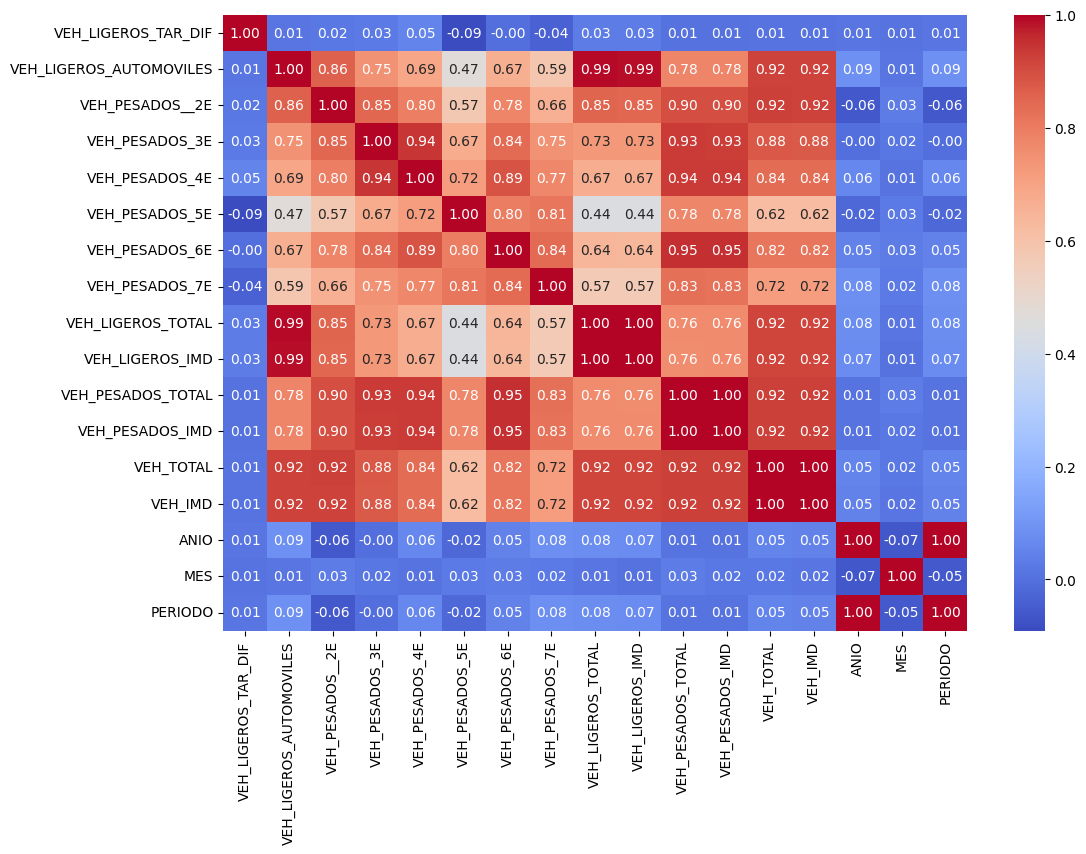

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df_num_imputed.corr()
mask = plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True
)


In [13]:
df_num_imputed

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO
0,102.814804,8070.00,2586.0,2374.0,720.000000,315.000000,3512.000000,8.00000,10169.000000,328.000000,9515.0,306.9,19684.0,635.0,2014.0,1.0,201401.0
1,0.000000,24644.00,6502.0,4622.0,1654.000000,3028.000000,8711.000000,213.00000,24644.000000,795.000000,24730.0,797.7,49374.0,1592.7,2014.0,1.0,201401.0
2,7.211207,82139.00,17981.0,5307.0,1150.000000,1737.000000,5342.000000,12.00000,85932.622101,2851.164583,37326.0,1204.1,153108.0,4939.0,2014.0,1.0,201401.0
3,10.000000,46944.00,16981.0,18585.0,4463.000000,3058.000000,19400.000000,135.00000,46954.000000,1514.600000,62622.0,2020.1,109576.0,3534.7,2014.0,1.0,201401.0
4,0.000000,23831.00,4709.0,3941.0,447.000000,769.000000,3945.000000,95.00000,23831.000000,768.700000,13906.0,448.6,37737.0,1217.3,2014.0,1.0,201401.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10776,660.000000,3609.00,808.0,603.0,605.000000,2553.000000,859.000000,3.00000,4269.000000,142.300000,5431.0,181.0,9700.0,323.3,2025.0,6.0,202506.0
10777,0.000000,117.24,44.3,76.8,36.844361,63.640417,222.992208,2.73875,0.000000,0.000000,0.0,0.0,0.0,0.0,2025.0,6.0,202506.0
10778,0.000000,31078.00,3209.0,965.0,290.000000,221.000000,489.000000,4.00000,31078.000000,1035.900000,5178.0,172.6,36256.0,1208.5,2025.0,6.0,202506.0
10779,0.000000,117.24,44.3,76.8,36.844361,63.640417,222.992208,2.73875,0.000000,0.000000,0.0,0.0,0.0,0.0,2025.0,6.0,202506.0


In [14]:
df_prep_cat  

,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO
0,Concesionado,22PE5NACS1,San Martín
1,Concesionado,04PE1SCAM1,Arequipa
2,Concesionado,21PE3SCRO1,Puno
3,Concesionado,12PE3NCRA1,Junín
4,Concesionado,08PE3SCSC1,Cusco
...,...,...,...
10776,No concesionado,21PE36ASIC1,Puno
10777,No concesionado,05PE28ASOC1,Ayacucho
10778,No concesionado,20PE1NLTGD1,Piura
10779,No concesionado,15PE16TNA1,Lima


In [15]:
df_total_imputed = pd.concat([df_num_imputed, df_prep_cat], axis=1)

In [17]:
df_total_imputed.head()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO
0,102.814804,8070.0,2586.0,2374.0,720.0,315.0,3512.0,8.0,10169.000000,328.000000,9515.0,306.9,19684.0,635.0,2014.0,1.0,201401.0,Concesionado,22PE5NACS1,San Martín
1,0.000000,24644.0,6502.0,4622.0,1654.0,3028.0,8711.0,213.0,24644.000000,795.000000,24730.0,797.7,49374.0,1592.7,2014.0,1.0,201401.0,Concesionado,04PE1SCAM1,Arequipa
2,7.211207,82139.0,17981.0,5307.0,1150.0,1737.0,5342.0,12.0,85932.622101,2851.164583,37326.0,1204.1,153108.0,4939.0,2014.0,1.0,201401.0,Concesionado,21PE3SCRO1,Puno
3,10.000000,46944.0,16981.0,18585.0,4463.0,3058.0,19400.0,135.0,46954.000000,1514.600000,62622.0,2020.1,109576.0,3534.7,2014.0,1.0,201401.0,Concesionado,12PE3NCRA1,Junín
4,0.000000,23831.0,4709.0,3941.0,447.0,769.0,3945.0,95.0,23831.000000,768.700000,13906.0,448.6,37737.0,1217.3,2014.0,1.0,201401.0,Concesionado,08PE3SCSC1,Cusco


In [19]:
df_total_imputed.to_csv('../Data/Processed/Flujo_Vehicular_procesado.csv', encoding='latin-1', index=False)